In [1]:
import ipdb
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import nn

In [2]:
NUM_SAMPLES = 50000
MAX_TIME = 2
R = 10e3
C = 10e-6
V0 = 0
V_max = 5

class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.tensor:
        logits = self.linear_relu_stack(x)
        return logits

In [3]:
EPOCHS = 1000
# get data
init_conditions = (0, V0)
# one batch of data
T = torch.tensor(np.sort(np.random.rand(NUM_SAMPLES) * MAX_TIME).reshape(NUM_SAMPLES, 1), dtype=torch.float,requires_grad=True)
# easy dimensions fix (NUM_SAMPLES x 1)
# apparently, this thing messes up with the gradient function of the tensor
# the reshaping makes this not work? how wierd
# needed to make all reshaping and re-typing operations in numpy, previous to tensor convert.
# T = T.reshape(T.shape[0], 1).type(torch.float)
print("The shape of the input is: ", end='')
print(T.shape)

# define model
v = PINN().to("cpu")

# define the optimizer
learning_rate = 1e-3
optimizer = torch.optim.SGD(v.parameters(), lr=learning_rate)

loss_accum = []
for i in tqdm(range(EPOCHS)):
    v_T = v(T)
    V = torch.sum(v_T)
    V.backward()
    loss = (T.grad + T/(R*C) - V_max/(R*C)) ** 2
    L = torch.mean(loss)
    loss_accum.append(L.item())
    optimizer.zero_grad()
    L.backward()
    optimizer.step()
    optimizer.zero_grad()
    T.grad.zero_()



The shape of the input is: torch.Size([50000, 1])


  0%|          | 0/1000 [00:00<?, ?it/s]/home/ssuarez/tutorials/pytorch_tutorial/.env/lib/python3.9/site-packages/torch/autograd/__init__.py:251: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11050). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
100%|██████████| 1000/1000 [00:42<00:00, 23.31it/s]


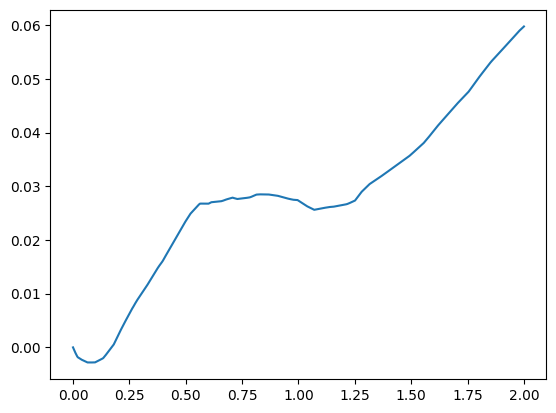

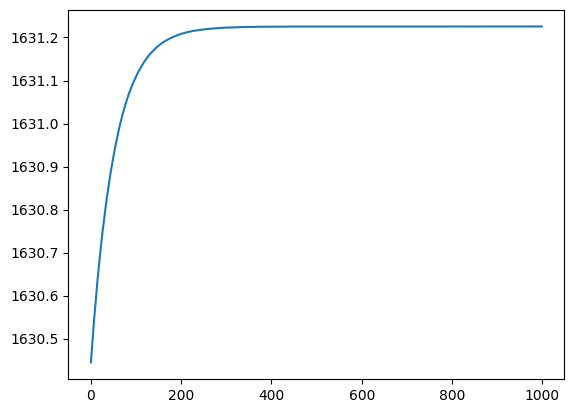

In [5]:
V = v(T)
plt.figure()
plt.plot(T.detach().numpy(), V.detach().numpy())
plt.show()
plt.figure()
plt.plot(loss_accum)
plt.show()